# Customer Chern Prediction using Neural Network
* Chern prediction is used to predict how many customers are leaving a particular service.
* The goal of this project is to gasp the deep understanding of deep learning libraries like tensorflow and keras 
* Here we will be doing binary classification of the data in this model

In [1]:
import numpy as np
import pandas as pd

In [2]:
df= pd.read_csv("dataset/Churn_Modelling.csv")
print(df.shape)
df.head() ## First 10 elements

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info() ##to check for missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.duplicated().sum() ## No duplicate row

np.int64(0)

In [5]:
df["Exited"].value_counts()
## here 1 -> exites and 0 ->remains
# its imbalanced

Exited
0    7963
1    2037
Name: count, dtype: int64

In [6]:
df["Geography"].value_counts() # its imbalanced

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
df["Gender"].value_counts() # its balanced

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [8]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)
# inplace=True does the changes to the original dataset

In [9]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int) # Onehot encoding in pd
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [11]:
## Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(df.drop(columns=['Exited']),df['Exited'],test_size=0.2,random_state=1)

In [12]:
X_test

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9953,550,47,2,0.00,2,1,1,97057.28,0,0,1
3850,680,34,3,143292.95,1,1,0,66526.01,0,0,1
4962,531,42,2,0.00,2,0,1,90537.47,0,0,0
3886,710,34,8,147833.30,2,0,1,1561.58,1,0,1
5437,543,30,6,73481.05,1,1,1,176692.65,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
3919,763,39,7,0.00,2,1,0,19458.75,0,1,0
162,800,49,7,108007.36,1,0,0,47125.11,0,0,0
7903,567,34,10,0.00,2,0,1,161571.79,0,1,1
2242,621,30,2,101014.08,2,1,1,165257.31,1,0,0


In [13]:
#here we are Standardaizing the values around 0

from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled= scaler.fit_transform(X_train) # it will fit and transform the value of X-train at the same time
X_test_scaled=scaler.transform(X_test) # it will transform the value of X-test

In [14]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

### import libraries


In [15]:
#import libraries

import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import Sequential 
#Sequential: Layers are stacked one after another in this model
# Input → Dense → Dense → Dense → Output
from tensorflow.keras.layers import Dense
# Dense is a fully connected layer
# in dense each neuron connects to every neuron in the previous layer


### Architecture of Neural Network Model


In [16]:
## Architecture of Neural Network Model

model=Sequential()
# Layer 1 [connected to inputs]
model.add(Dense(11,activation='relu',input_dim=11)) #3= No. of neurons, input_dim= No. of inputs 
# Layer 2 [new Hidden layer]
model.add(Dense(11,activation='relu'))
# Layer 3 [new Hidden layer]
model.add(Dense(11,activation='relu'))
# Layer 4 [Output Layer]
model.add(Dense(1,activation='sigmoid'))

c:\Users\vaibh\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408 (1.59 KB)

 Trainable params: 408 (1.59 KB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation stage
* what loss function is used??
* what optimizer is used for gradient descent??


In [18]:
## model.compile(loss='binary_crossentropy', optimizer='Adam' )

In [19]:
model.compile(loss='binary_crossentropy', optimizer='Adam',metrics=['accuracy'])
# Optimizer = Adam is a type of gradient descent optimizer

# here we are also definig a new metric for accuracy so,
# during training we will also obtain Accuracy 

### Train the model

In [20]:
## model.fit(X_train_scaled,Y_train,epochs= 100)

#### validation_split

It means:

* Use 20% of training data for validation
* Use 80% for actual training

So if you had 1000 samples: 800 → training, 200 → validation

Validation data:
* Not used to update weights
* Used to evaluate performance after each epoch

### This helps detect: Overfitting, Underfitting

In [21]:
history= model.fit(X_train_scaled,Y_train,epochs= 100, validation_split=0.2)
## save the data in the history dictionary
# this dictionary 


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7961 - loss: 0.5057 - val_accuracy: 0.7956 - val_loss: 0.4726
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8012 - loss: 0.4539 - val_accuracy: 0.7987 - val_loss: 0.4493
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8087 - loss: 0.4387 - val_accuracy: 0.8062 - val_loss: 0.4367
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8173 - loss: 0.4291 - val_accuracy: 0.8125 - val_loss: 0.4270
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8269 - loss: 0.4200 - val_accuracy: 0.8219 - val_loss: 0.4177
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8306 - loss: 0.4111 - val_accuracy: 0.8219 - val_loss: 0.4112
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8316 - loss: 0.4037 - val_accuracy: 0.8238 - val_loss: 0.4043
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8333 - loss: 0.3937 - val_accu

### Note: 

a little bit of overfitting can be seen as the validation accuracy is 85% and the actual accuracy is 86% similarly for validation loss is 34.6% and actual loss is 31% very less when compared to validation 

Hence we can interpret that the model is giving better result for the input/ training data that it has seen whereas its accuracy is less on the validation data which it has not seen

### Plotting the accuracy and loss

In [22]:
print(history) # History is a history object
history.history # history of the dictionary

{'accuracy': [0.796093761920929,
  0.8012499809265137,
  0.8087499737739563,
  0.8173437714576721,
  0.8268749713897705,
  0.8306249976158142,
  0.8315625190734863,
  0.8332812786102295,
  0.8373437523841858,
  0.8459374904632568,
  0.854687511920929,
  0.8576562404632568,
  0.858593761920929,
  0.8603125214576721,
  0.860156238079071,
  0.8631250262260437,
  0.8617187738418579,
  0.8609374761581421,
  0.8665624856948853,
  0.86328125,
  0.8637499809265137,
  0.8637499809265137,
  0.8643749952316284,
  0.8639062643051147,
  0.8660937547683716,
  0.8662499785423279,
  0.8660937547683716,
  0.8656250238418579,
  0.8673437237739563,
  0.866406261920929,
  0.8660937547683716,
  0.8668749928474426,
  0.867968738079071,
  0.8689062595367432,
  0.8665624856948853,
  0.8660937547683716,
  0.8668749928474426,
  0.8665624856948853,
  0.8670312762260437,
  0.8676562309265137,
  0.8678125143051147,
  0.8654687404632568,
  0.8682812452316284,
  0.867968738079071,
  0.8673437237739563,
  0.867031276

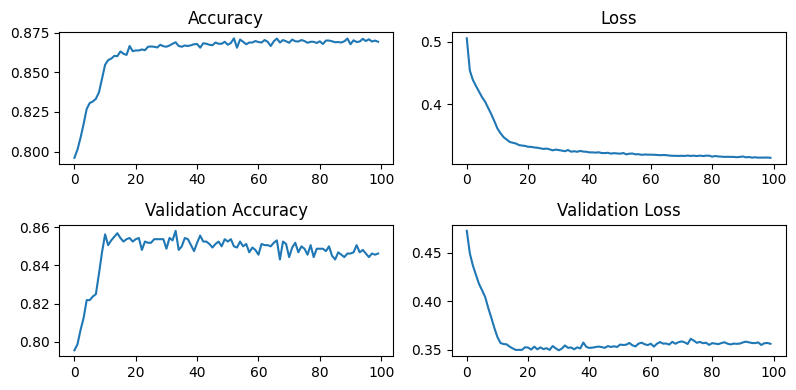

In [23]:
import matplotlib.pyplot as plt
fig, axis=plt.subplots(2,2, figsize=(8,4)) # plotting a fig with 1 row and 2 column

# Actual Loss and Accuracy
axis[0][0].plot(history.history['accuracy'])
axis[0][1].plot(history.history['loss'])
axis[0][0].set_title('Accuracy')
axis[0][1].set_title('Loss')

# Validation Loss annd Profit
axis[1][0].plot(history.history['val_accuracy'])
axis[1][1].plot(history.history['val_loss'])
axis[1][0].set_title('Validation Accuracy')
axis[1][1].set_title('Validation Loss')

plt.tight_layout()

### To obtain weights and biases

In [24]:
model.layers[0].get_weights()
## We get first all of the weights [11x3] and then all of the basis of Layer 0

[array([[ 3.77856381e-02, -8.70332718e-02,  1.84497908e-02,
         -6.81167468e-02, -4.15122688e-01, -3.41024660e-02,
         -6.06031679e-02, -4.07985121e-01,  9.08595249e-02,
         -6.79046363e-02, -1.18991122e-01],
        [ 6.25925899e-01, -5.18885732e-01, -5.07545173e-01,
          8.52640688e-01,  1.71565562e-01, -2.61402071e-01,
          8.92782137e-02, -3.21183026e-01,  1.27772117e+00,
          1.26599535e-01, -5.15205562e-01],
        [ 4.38244753e-02,  3.89486670e-01, -6.76728599e-03,
          2.30631694e-01,  1.66170239e-01, -3.62471431e-01,
          5.34531623e-02,  5.06466604e-05, -1.26244262e-01,
          4.29987572e-02, -1.94377154e-02],
        [ 1.52809873e-01,  9.30871293e-02, -4.04700458e-01,
         -5.42942822e-01,  1.69667885e-01, -4.59503561e-01,
          3.38967204e-01, -8.03086698e-01,  3.95089276e-02,
          1.30965978e-01, -1.63128570e-01],
        [-4.32169765e-01,  2.70222217e-01,  6.81999624e-02,
          1.64816737e-01, -2.63943360e-03, -

In [25]:
model.layers[1].get_weights()
## We get first all of the weights [11x3] and then all of the basis of Layer 1

[array([[ 0.4386807 , -0.72386456, -0.1349545 , -0.04373752, -0.08302542,
          0.23334804, -0.29625052, -0.2905642 , -0.34489962, -0.27145338,
          0.14752227],
        [-0.11669151,  0.4773654 ,  0.04517474, -1.0043596 , -0.07709295,
         -0.22207545,  0.05271303, -0.5512984 ,  0.1877683 ,  0.26908094,
          0.03692542],
        [ 0.09760885,  0.42600372,  0.2960506 , -0.09808753,  0.21396178,
          0.45839465,  0.05489974, -0.32306364, -0.34458238, -0.44700807,
          0.7133813 ],
        [ 0.3930135 , -0.13797072,  0.37683907,  0.579909  ,  0.2615666 ,
         -0.16578406, -0.38593203,  0.3035538 ,  0.79153466, -0.01139841,
         -0.13941024],
        [ 0.24222119,  0.13541034,  0.47136113,  0.06951026, -0.38018712,
         -0.3529923 ,  0.27278006,  0.48359677,  0.4839897 ,  0.2288548 ,
         -0.5643005 ],
        [-0.08640682, -0.2701334 ,  0.60613   , -0.00533804,  0.5966281 ,
         -0.00414724, -0.00293008,  0.364566  ,  0.16824411,  0.0125281

### To Predict

In [26]:
model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.10214368],
       [0.08089709],
       [0.08335773],
       ...,
       [0.00360277],
       [0.02797628],
       [0.3156658 ]], dtype=float32)

In [33]:
## Since prediction is not 1 or 0 se we will use a threshold value here[0.5]

y_log=model.predict(X_test_scaled)
y_pred= np.where(y_log>0.45,1,0)
print(y_pred)
# Syntax: np.where(Conditon,If condution is True set y_log to 1, If condution is False set y_log to 0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]


### Accuracy

### Points to remember for increasing accuracy:
1. Increase the number of epochs
2. Generally Model performs better when the hidden layers have ReLu activation function
3. increase the no. of nodes in the hidden layers
4. increase the number of hidden layers [Excessive no. of hidden layers can lead to overfitting of the data]

In [34]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,Y_test)

0.8595